[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 03 - Base de datos propia
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [49]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **🚀 Viral Social Media Trends & Engagement Analysis** directamente desde el repositorio Kaggle.

In [30]:
df = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv', encoding='utf-8-sig')
print(f'Dataset cargado — {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado — 5000 registros, 11 columnas


,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,2022-01-13,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,2022-05-13,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,2022-01-07,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,2022-12-05,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,2023-03-23,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


---
## 3. Etapa 2 — Exploración y preparación de datos

In [31]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Post_ID           5000 non-null   str  
 1   Post_Date         5000 non-null   str  
 2   Platform          5000 non-null   str  
 3   Hashtag           5000 non-null   str  
 4   Content_Type      5000 non-null   str  
 5   Region            5000 non-null   str  
 6   Views             5000 non-null   int64
 7   Likes             5000 non-null   int64
 8   Shares            5000 non-null   int64
 9   Comments          5000 non-null   int64
 10  Engagement_Level  5000 non-null   str  
dtypes: int64(4), str(7)
memory usage: 429.8 KB




,Views,Likes,Shares,Comments
count,5000.00,5000.00,5000.00,5000.00
mean,2494066.44,251475.03,50519.56,24888.39
std,1459489.82,144349.58,29066.36,14284.50
min,1266.00,490.00,52.00,18.00
25%,1186207.25,126892.25,25029.00,12305.25
50%,2497373.00,249443.00,50839.50,25004.00
75%,3759781.00,373970.75,75774.25,37072.75
max,4999430.00,499922.00,99978.00,49993.00


In [32]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

df = df.drop_duplicates().reset_index(drop=True)
print(f'Registros después de limpieza: {df.shape[0]}')

Valores nulos por columna:
Post_ID             0
Post_Date           0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
dtype: int64

Registros duplicados: 0
Registros después de limpieza: 5000


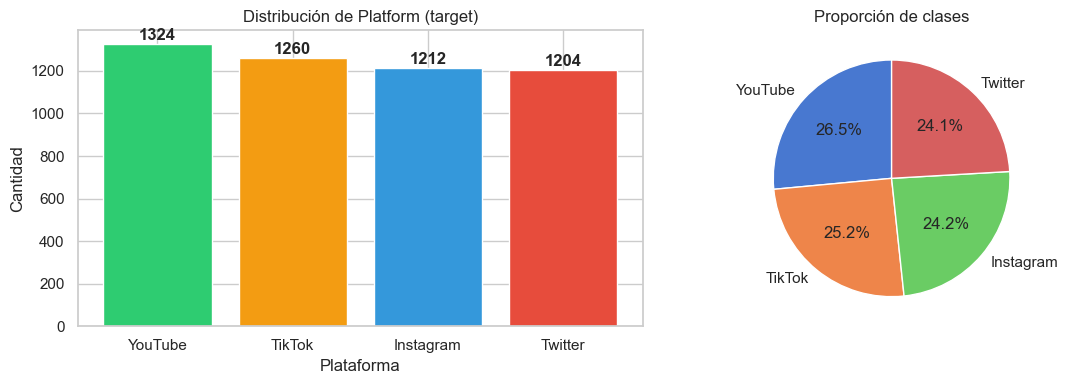

In [33]:
# 3.3  Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['Platform'].value_counts()
axes[0].bar(target_counts.index, target_counts.values,
            color=['#2ecc71', '#f39c12', '#3498db', '#e74c3c'])
axes[0].set_title('Distribución de Platform (target)')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

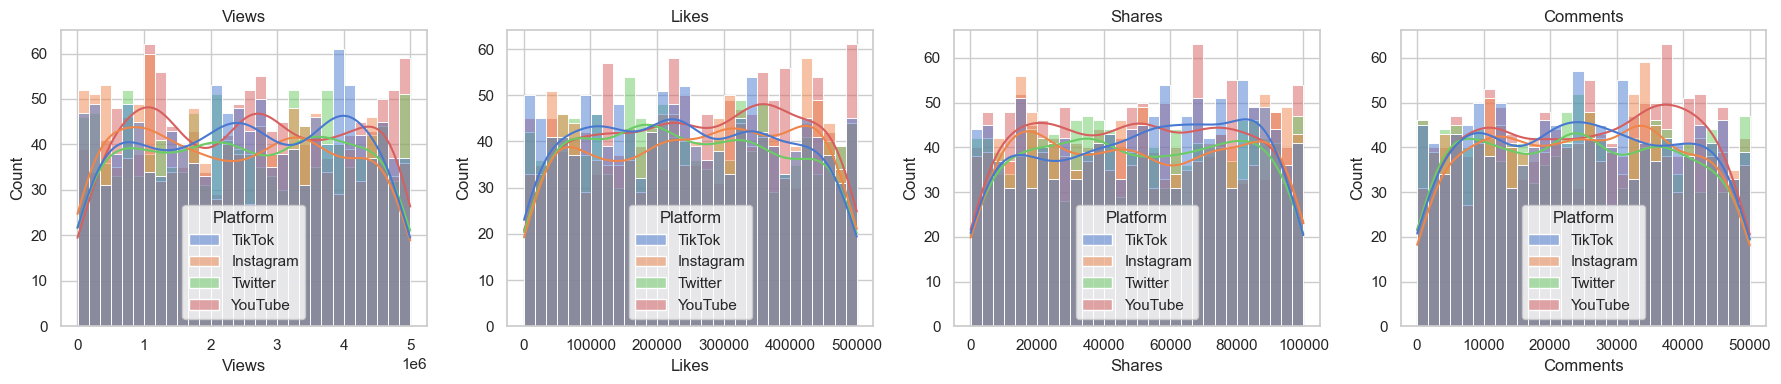

In [34]:
# 3.4  Distribución de variables numéricas clave
num_cols = ['Views', 'Likes', 'Shares', 'Comments']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Platform', kde=True, ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

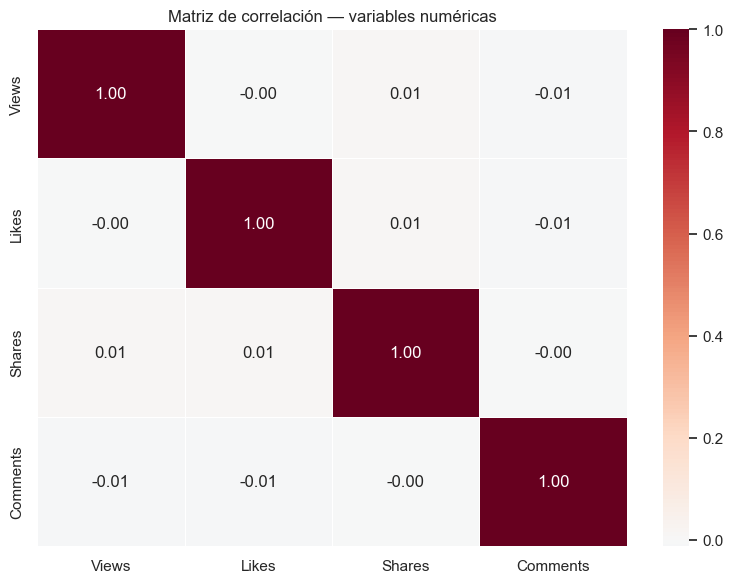

In [35]:
# 3.5  Matriz de correlación
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [36]:
# 4.1  Feature engineering ligero sobre Post_Date
df['Post_Date'] = pd.to_datetime(df['Post_Date'])
df['Year']  = df['Post_Date'].dt.year
df['Month'] = df['Post_Date'].dt.month
df['Day']   = df['Post_Date'].dt.day

# Eliminar identificador y fecha original
df = df.drop(columns=['Post_ID', 'Post_Date'])

# 4.2  Separación features / target
X = df.drop(columns='Platform')   
y = df['Platform']               

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')
print(f'\nClases del target: {sorted(y.unique())}')
print(f'Distribución:\n{y.value_counts()}')

Features: (5000, 11)
Target:   (5000,)

Clases del target: ['Instagram', 'TikTok', 'Twitter', 'YouTube']
Distribución:
Platform
YouTube      1324
TikTok       1260
Instagram    1212
Twitter      1204
Name: count, dtype: int64


In [37]:
numeric_features     = ['Views', 'Likes', 'Shares', 'Comments', 'Year', 'Month', 'Day']
categorical_features = ['Hashtag', 'Content_Type', 'Region', 'Engagement_Level']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [38]:
# 4.4   Split stratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')

Train: 4000 muestras
Test:  1000 muestras

Proporción target en train:
Platform
YouTube      0.265
TikTok       0.252
Instagram    0.242
Twitter      0.241
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [39]:
# 5.1  Definición de pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('prep', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
    ])
}

results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.2510 ± 0.0198
DecisionTree               Accuracy CV: 0.2470 ± 0.0133
RandomForest               Accuracy CV: 0.2535 ± 0.0069


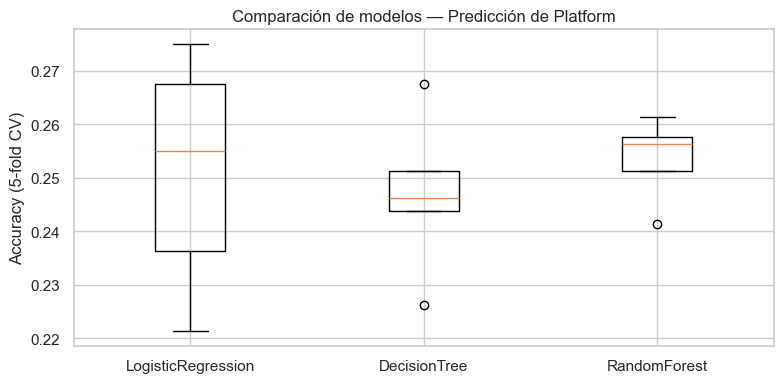

In [40]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Predicción de Platform')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [41]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred))

Mejor modelo: RandomForest
Accuracy en test: 0.2710

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Instagram       0.28      0.20      0.24       242
      TikTok       0.25      0.25      0.25       252
     Twitter       0.25      0.17      0.20       241
     YouTube       0.29      0.45      0.35       265

    accuracy                           0.27      1000
   macro avg       0.27      0.27      0.26      1000
weighted avg       0.27      0.27      0.26      1000



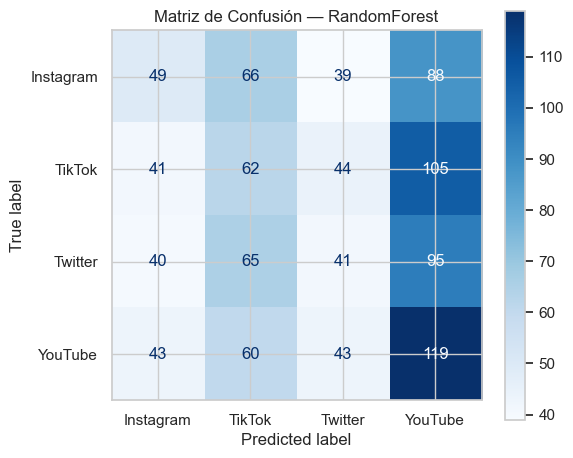

In [42]:
# 6.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

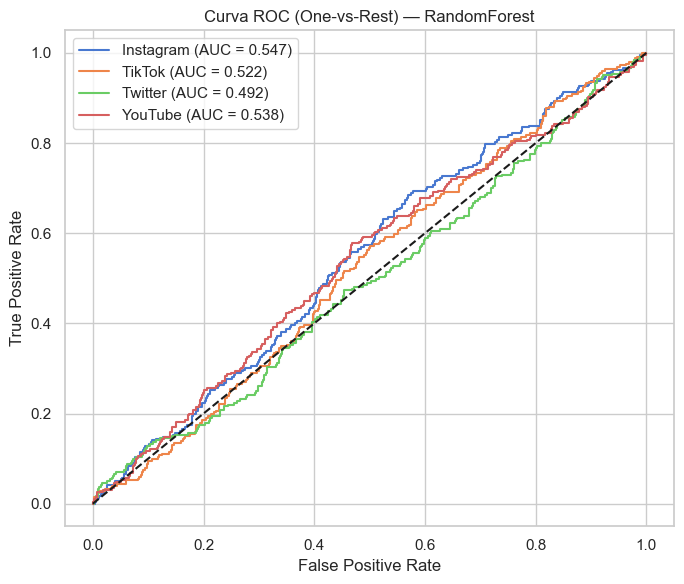

In [50]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
classes = best_pipeline.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_pipeline.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    ax.plot(fpr, tpr, label=f'{cls} (AUC = {auc(fpr, tpr):.3f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Curva ROC (One-vs-Rest) — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [51]:
# 7.1  Guardar el modelo
MODEL_PATH = 'viral_social_media_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

# Verificación
loaded_model = joblib.load(MODEL_PATH)
assert np.array_equal(loaded_model.predict(X_test), y_pred)
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Modelo guardado en: viral_social_media_model.joblib
Verificación OK: el modelo cargado reproduce las predicciones.


In [52]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [53]:
# 7.3  Función de inferencia (simula un endpoint de predicción)

def predict_platform(post_data: dict) -> dict:
    """
    Recibe un dict con las features de un post y predice en qué plataforma
    tuvo más probabilidad de publicarse.
    """
    model = joblib.load(MODEL_PATH)
    input_df = pd.DataFrame([post_data])
    pred  = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]
    classes = model.classes_

    return {
        'plataforma_predicha': pred,
        'probabilidades': {cls: round(float(p), 4) for cls, p in zip(classes, proba)}
    }

# Ejemplo
post_ejemplo = {
    'Hashtag': '#Dance',
    'Content_Type': 'Video',
    'Region': 'USA',
    'Engagement_Level': 'High',
    'Views': 1_500_000,
    'Likes': 250_000,
    'Shares': 40_000,
    'Comments': 20_000,
    'Year': 2023, 'Month': 6, 'Day': 15
}

resultado = predict_platform(post_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  plataforma_predicha: Twitter
  probabilidades: {'Instagram': 0.2464, 'TikTok': 0.2441, 'Twitter': 0.2658, 'YouTube': 0.2437}


---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*